In [1]:
import pandas as pd

In [2]:
dataset = pd.read_csv('AAPL_data.csv')

In [3]:
dataset.head

<bound method NDFrame.head of             date      open      high       low     close     volume  Name
0     2013-02-08   67.7142   68.4014   66.8928   67.8542  158168416  AAPL
1     2013-02-11   68.0714   69.2771   67.6071   68.5614  129029425  AAPL
2     2013-02-12   68.5014   68.9114   66.8205   66.8428  151829363  AAPL
3     2013-02-13   66.7442   67.6628   66.1742   66.7156  118721995  AAPL
4     2013-02-14   66.3599   67.3771   66.2885   66.6556   88809154  AAPL
...          ...       ...       ...       ...       ...        ...   ...
1254  2018-02-01  167.1650  168.6200  166.7600  167.7800   47230787  AAPL
1255  2018-02-02  166.0000  166.8000  160.1000  160.5000   86593825  AAPL
1256  2018-02-05  159.1000  163.8800  156.0000  156.4900   72738522  AAPL
1257  2018-02-06  154.8300  163.7200  154.0000  163.0300   68243838  AAPL
1258  2018-02-07  163.0850  163.4000  159.0685  159.5400   51608580  AAPL

[1259 rows x 7 columns]>

In [4]:
dataset= dataset.values

In [5]:
open_value= dataset[:,1]

In [6]:
from matplotlib import pyplot as plt

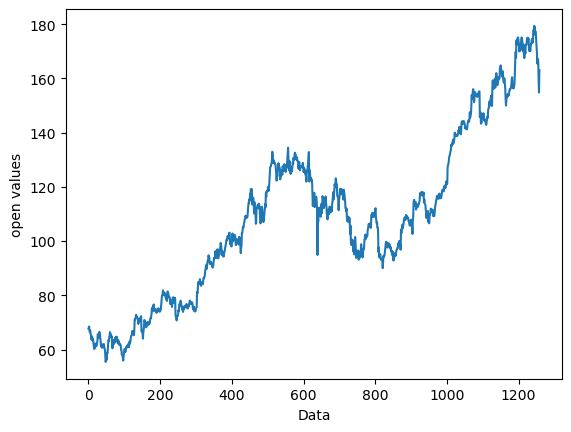

In [7]:
plt.plot(open_value)
plt.xlabel("Data")
plt.ylabel("open values")
plt.show()

In [8]:
open_value = open_value.reshape(-1,1)

In [9]:
from sklearn.preprocessing import MinMaxScaler

In [10]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_open_value = scaler.fit_transform(open_value)

In [11]:
print(open_value[:5].T)

[[67.7142 68.0714 68.5014 66.7442 66.3599]]


In [12]:
print(scaled_open_value[:5].T)

[[0.09915624 0.10203815 0.10550741 0.09133024 0.08822969]]


In [13]:
data = []
target = []

In [14]:
window_size = 50

In [15]:
for i in range(0,len(open_value)-window_size):
    data.append(scaled_open_value[i: i+window_size])
    target.append(scaled_open_value[i+window_size])

In [16]:
import numpy as np

In [17]:
data= np.array(data)
target = np.array(target)

In [18]:
print(data.shape)

(1209, 50, 1)


In [19]:
print(target.shape)

(1209, 1)


In [20]:
train_data = data[:1000]
train_target = target[:1000]
test_data = data[1000:]
test_target = target[1000:]

In [21]:
test_x_range = np.arange(1000,1209,1)

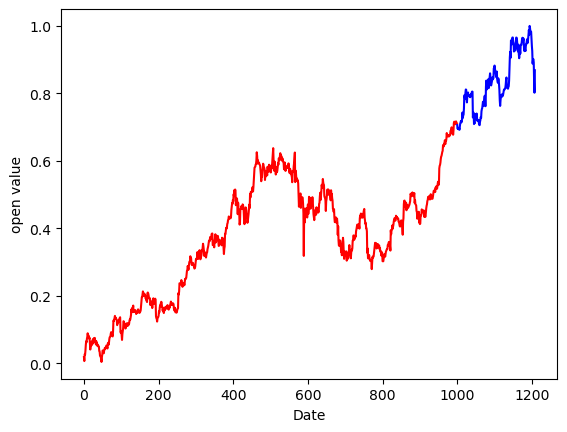

In [22]:
plt.plot(train_target,'r',label ='train')
plt.plot(test_x_range,test_target, 'b',label ='test')
plt.xlabel('Date')
plt.ylabel('open value')
plt.show()

In [23]:
from keras.models import Sequential

In [24]:
from keras.layers import LSTM,Dense, Dropout, Input

In [25]:
model = Sequential()

In [26]:
model.add(Input(shape=data.shape[1:]))

In [27]:
model.add(LSTM(units=96,return_sequences = True))
model.add(Dropout(0.2))

In [28]:
model.add(LSTM(units=96,return_sequences = True))
model.add(Dropout(0.2))

In [29]:
model.add(LSTM(units=96,return_sequences = True))
model.add(Dropout(0.2))

In [30]:
model.add(LSTM(units=40,return_sequences = False))
model.add(Dropout(0.2))

In [31]:
model.add(Dense(units=1,activation = 'linear'))

In [32]:
model.compile(loss='mse',optimizer = 'adam')

In [33]:
history = model.fit(train_data,train_target,epochs=200,validation_split= 0.1)

Epoch 1/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 14s 159ms/step - loss: 0.0126 - val_loss: 0.0029
Epoch 2/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - loss: 0.0032 - val_loss: 0.0017
Epoch 3/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0036 - val_loss: 0.0040
Epoch 4/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - loss: 0.0026 - val_loss: 0.0136
Epoch 5/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - loss: 0.0036 - val_loss: 0.0077
Epoch 6/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - loss: 0.0029 - val_loss: 0.0076
Epoch 7/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step - loss: 0.0025 - val_loss: 6.8811e-04
Epoch 8/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 120ms/step - loss: 0.0024 - val_loss: 0.0024
Epoch 9/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - loss: 0.0022 - val_loss: 0.0012
Epoch 10/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - loss: 0.0023 - val_loss: 7.5291e-04
Epoch 11/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - loss: 0.0020 - val_loss: 0.0098
Epoch 12/200
29/29 ━━━━━━━━━━━━━

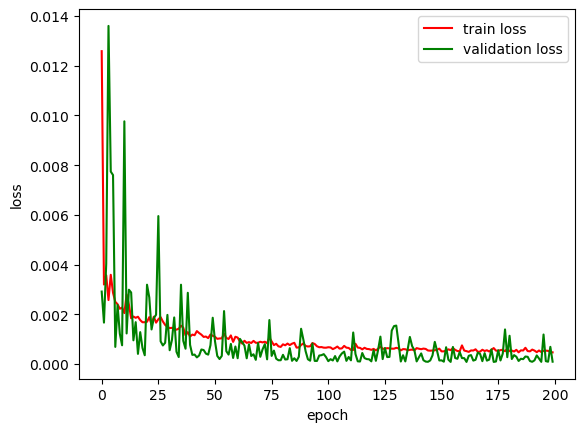

In [34]:
plt.plot(history.history['loss'],'r',label='train loss')
plt.plot(history.history['val_loss'],'g',label='validation loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [35]:
result=model.predict(test_data)

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 244ms/step


In [36]:
from sklearn.metrics import r2_score

In [37]:
r2=r2_score(test_target,result)
print('r2 score:',r2)

r2 score: 0.9544603153250423


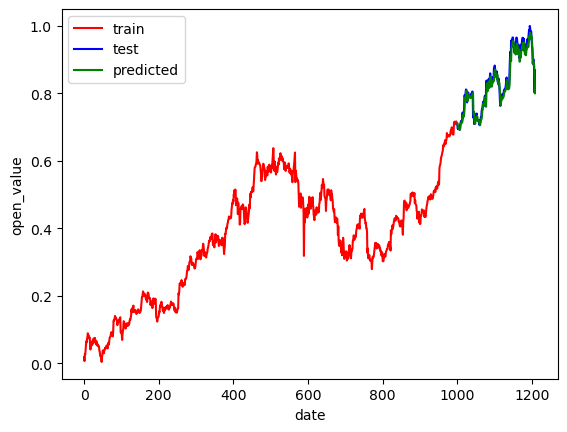

In [38]:
plt.plot(train_target,'r',label='train')
plt.plot(test_x_range,test_target,'b',label='test')
plt.plot(test_x_range,result,'g',label='predicted')
plt.xlabel('date')
plt.ylabel('open_value')
plt.legend()
plt.show()        

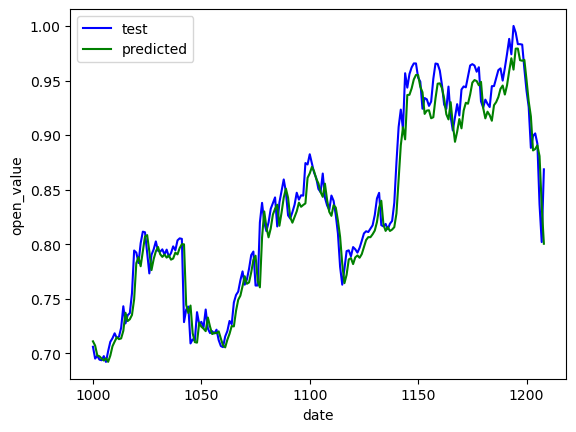

In [39]:
plt.plot(test_x_range,test_target,'b',label='test')
plt.plot(test_x_range,result,'g',label='predicted')
plt.xlabel('date')
plt.ylabel('open_value')
plt.legend()
plt.show()   

In [40]:
model.save('stock-market.keras')

In [41]:
import joblib

In [42]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']